# 1. Optimizar una función

Se desea resolver mediante un **Algoritmo Genético Simple (AGS)**:

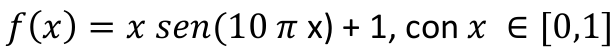

El objetivo es encontrar el valor de \(x\) que produzca el mayor valor posible de \(f(x)\).

Se siuge la metodología presentada por el profe en el documento **Algoritmos Genéticos**:

1. Definir el problema.
2. Definir la representación de los individuos.
3. Definir la función de aptitud.
4. Generar una población inicial.
5. Seleccionar los individuos más aptos.
6. Aplicar cruce.
7. Aplicar mutación.
8. Crear una nueva generación.
9. Repetir el proceso hasta cumplir el criterio de parada.
10. Analizar la mejor solución encontrada.

# 1. Comprender la función que queremos maximizar

La función es:

Como aparece un seno, la función presenta varios máximos y mínimos dentro del intervalo \([0,1]\).

Por esta razón en lugar de partir de un único punto, se trabajará simultáneamente con una población de soluciones candidatas.

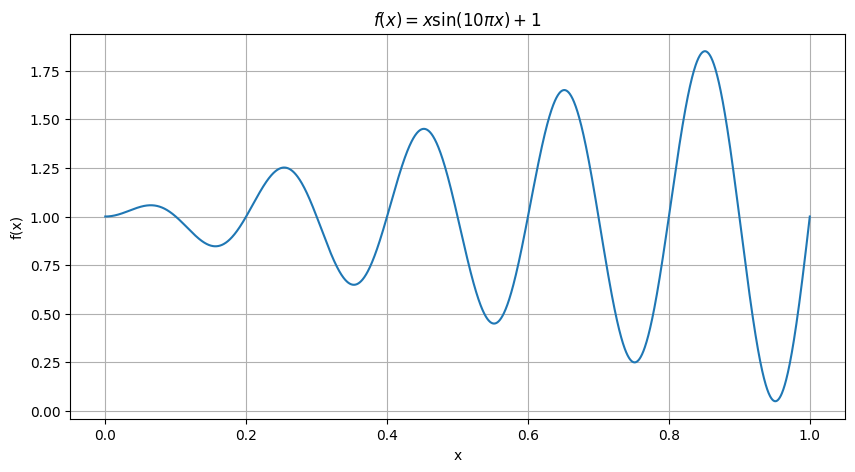

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd

def f(x):
    return x * np.sin(10 * np.pi * x) + 1


#Observamos la forma de la función. No ayuda a resolver el problema pero nos da a entender con qué estamos trabajando.
x_grafica = np.linspace(0, 1, 2000)
y_grafica = f(x_grafica)

plt.figure(figsize=(10,5))
plt.plot(x_grafica, y_grafica)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"$f(x)=x\sin(10\pi x)+1$")
plt.grid()
plt.show()

# 2. Representación del individuo

En un Algoritmo Genético Simple cada solución se representa mediante un **cromosoma binario**.

Usaremos l = 10 bits, por lo que existen 1024 cromosomas diferentes.

Cada cromosoma representa un número real \(x\) dentro del intervalo: [0,1]

Vale la pena aclarar que primero se convierte el cromosoma a decimal y después se transforma ese valor al intervalo real del problema.

## Decodificación del cromosoma

Si:

- \(D\) = valor decimal del cromosoma,
- \(l\) = número de bits,
- \(x_i\) = límite inferior,
- \(x_f\) = límite superior,

utilizaremos:

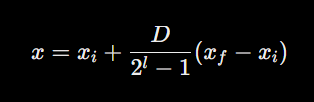

Como en nuestro problema x_i = 0 y x_f = 1, queda:

x = D/1023

In [ ]:
L = 10
X_MIN = 0
X_MAX = 1

def decimal_cromosoma(cromosoma):
    valor = 0
    for bit in cromosoma:
        valor = valor * 2 + bit
    return valor

def decodificar(cromosoma):
    D = decimal_cromosoma(cromosoma)
    return X_MIN + (D / (2**L - 1)) * (X_MAX - X_MIN)

### Ejemplo de decodificación

In [ ]:
ejemplo = [1,0,1,1,0,1,0,0,1,1]

D = decimal_cromosoma(ejemplo)
x = decodificar(ejemplo)

print("Cromosoma:", ejemplo)
print("Valor decimal:", D)
print("Valor real x:", x)
print("f(x):", f(x))

Cromosoma: [1, 0, 1, 1, 0, 1, 0, 0, 1, 1]
Valor decimal: 723
Valor real x: 0.7067448680351907
f(x): 0.8513615586770227


# 3. Función de aptitud

Esto es un poco obvio, pero como el objetivo es maximizar la función, entre mayor sea \f(x)\, más apto será el cromosoma.




In [ ]:
def aptitud(cromosoma):
    x = decodificar(cromosoma)
    return float(f(x))

# 4. Generar la población inicial

Usaremos una población de:

\[
K=20
\]

individuos.

Cada individuo tendrá 10 bits generados aleatoriamente.

In [ ]:
K = 20

def generar_poblacion(K, L):
    poblacion = []
    for _ in range(K):
        cromosoma = [random.randint(0,1) for _ in range(L)]
        poblacion.append(cromosoma)
    return poblacion

# 5. Evaluación de la población

Para cada cromosoma calculamos:

1. su valor decimal,
2. su valor real \(x\),
3. su aptitud \(f(x)\).

La suma de las aptitudes permitirá calcular posteriormente la probabilidad de selección.

In [ ]:
def evaluar_poblacion(poblacion):
    datos = []

    for cromosoma in poblacion:
        D = decimal_cromosoma(cromosoma)
        x = decodificar(cromosoma)
        fit = aptitud(cromosoma)

        datos.append({
            "cromosoma": "".join(map(str, cromosoma)),
            "decimal": D,
            "x": x,
            "aptitud": fit
        })

    return pd.DataFrame(datos)

tabla_inicial = evaluar_poblacion(poblacion)
tabla_inicial

,cromosoma,decimal,x,aptitud
0,0010000010,130,0.127077,0.904474
1,0000001011,11,0.010753,1.003564
2,0011100100,228,0.222874,1.146726
3,1011101010,746,0.729228,0.420614
4,1100001000,776,0.758553,0.268668
5,1111011010,986,0.963832,0.125743
6,0001110100,116,0.113392,0.953689
7,0111001011,459,0.448680,1.448295
8,1010011110,670,0.654936,1.647076
9,0100000101,261,0.255132,1.251823


# 6. Selección por ruleta

Los individuos con mayor aptitud reciben una mayor probabilidad de ser escogidos como padres.

Para cada cromosoma:

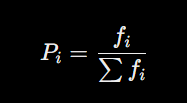

Los mejores cromosomas ocupan una porción mayor de la ruleta.

In [ ]:
def seleccion_ruleta(poblacion):
    aptitudes = np.array([aptitud(c) for c in poblacion], dtype=float)
    probabilidades = aptitudes / aptitudes.sum()

    indices = np.random.choice(
        len(poblacion),
        size=len(poblacion),
        replace=True,
        p=probabilidades
    )

    seleccionados = [poblacion[i].copy() for i in indices]
    return seleccionados

# 7. Cruce de un punto

Los cromosomas seleccionados se agrupan en parejas.

Ejemplo:

```text
Padre 1: 10110 | 10011
Padre 2: 01101 | 11100
```

Después del cruce:

```text
Hijo 1 : 10110 | 11100
Hijo 2 : 01101 | 10011
```

Así se combinan características de ambos padres.

In [ ]:
def cruce_un_punto(padre1, padre2, prob_cruce=0.9):
    if random.random() > prob_cruce:
        return padre1.copy(), padre2.copy()

    punto = random.randint(1, L-1)

    hijo1 = padre1[:punto] + padre2[punto:]
    hijo2 = padre2[:punto] + padre1[punto:]

    return hijo1, hijo2

# 8. Mutación

La mutación cambia ocasionalmente un bit. Usaremos:

\[
p_m=0.01
\]



In [ ]:
P_MUT = 0.01

def mutar(cromosoma, p_mut=P_MUT):
    nuevo = cromosoma.copy()

    for i in range(len(nuevo)):
        if random.random() < p_mut:
            nuevo[i] = 1 - nuevo[i]

    return nuevo

# 9. Creación de una nueva generación

Ahora combinamos selección, cruce y mutación manteniendo constante el tamaño de la población.

In [ ]:
def nueva_generacion(poblacion, prob_cruce=0.9, p_mut=P_MUT):
    padres = seleccion_ruleta(poblacion)
    nueva_poblacion = []

    for i in range(0, len(padres), 2):
        padre1 = padres[i]
        padre2 = padres[i+1] if i + 1 < len(padres) else padres[0]

        hijo1, hijo2 = cruce_un_punto(padre1, padre2, prob_cruce)

        nueva_poblacion.append(mutar(hijo1, p_mut))

        if len(nueva_poblacion) < len(poblacion):
            nueva_poblacion.append(mutar(hijo2, p_mut))

    return nueva_poblacion

# 10. Algoritmo Genético completo

Usaremos:

- Longitud del cromosoma: \(L=10\)
- Población: \(K=20\)
- Generaciones: \(M=50\)
- Probabilidad de cruce: \(0.90\)
- Probabilidad de mutación: \(0.01\)

También guardaremos el mejor individuo de cada generación para observar la convergencia.

In [ ]:
M = 50
PROB_CRUCE = 0.90

def algoritmo_genetico():
    poblacion = generar_poblacion(K, L)
    historial = []

    mejor_global = None
    mejor_aptitud_global = -np.inf

    for generacion in range(M + 1):
        aptitudes = [aptitud(c) for c in poblacion]
        indice_mejor = int(np.argmax(aptitudes))

        mejor = poblacion[indice_mejor].copy()
        mejor_fit = aptitudes[indice_mejor]
        mejor_x = decodificar(mejor)

        if mejor_fit > mejor_aptitud_global:
            mejor_global = mejor.copy()
            mejor_aptitud_global = mejor_fit

        historial.append({
            "generacion": generacion,
            "mejor_cromosoma": "".join(map(str, mejor)),
            "x": mejor_x,
            "mejor_aptitud": mejor_fit,
            "aptitud_promedio": float(np.mean(aptitudes))
        })

        if generacion < M:
            poblacion = nueva_generacion(
                poblacion,
                prob_cruce=PROB_CRUCE,
                p_mut=P_MUT
            )

    return mejor_global, pd.DataFrame(historial)

# 11. Ejecutar el algoritmo

In [ ]:
mejor_cromosoma, historial = algoritmo_genetico()

mejor_x = decodificar(mejor_cromosoma)
mejor_y = aptitud(mejor_cromosoma)

print("Mejor cromosoma:", "".join(map(str, mejor_cromosoma)))
print("Mejor x encontrado:", mejor_x)
print("Valor máximo aproximado f(x):", mejor_y)

Mejor cromosoma: 1101100101
Mejor x encontrado: 0.8494623655913979
Valor máximo aproximado f(x): 1.8493412004539471


# 12. Historial de generaciones

La tabla permite observar el mejor cromosoma, el valor de \(x\), la mejor aptitud y la aptitud promedio de cada generación.

In [ ]:
historial

,generacion,mejor_cromosoma,x,mejor_aptitud,aptitud_promedio
0,0,1101010111,0.835777,1.753724,1.020272
1,1,1101010100,0.832845,1.714786,1.329308
2,2,1101010100,0.832845,1.714786,1.320993
3,3,1101110100,0.864125,1.780431,1.353032
4,4,1101101110,0.858260,1.829525,1.361788
5,5,1101100101,0.849462,1.849341,1.449658
6,6,1010100100,0.660802,1.623119,1.328934
7,7,1010100001,0.657869,1.637869,1.202967
8,8,1010100001,0.657869,1.637869,1.304337
9,9,1010100001,0.657869,1.637869,1.376451


# 13. Gráfica de convergencia

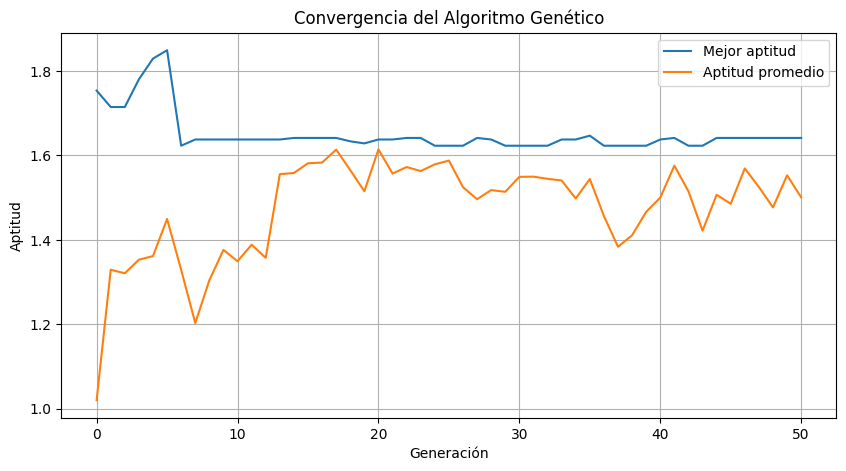

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(historial["generacion"], historial["mejor_aptitud"], label="Mejor aptitud")
plt.plot(historial["generacion"], historial["aptitud_promedio"], label="Aptitud promedio")
plt.xlabel("Generación")
plt.ylabel("Aptitud")
plt.title("Convergencia del Algoritmo Genético")
plt.grid()
plt.legend()
plt.show()

# 14. Mostrar la solución sobre la función

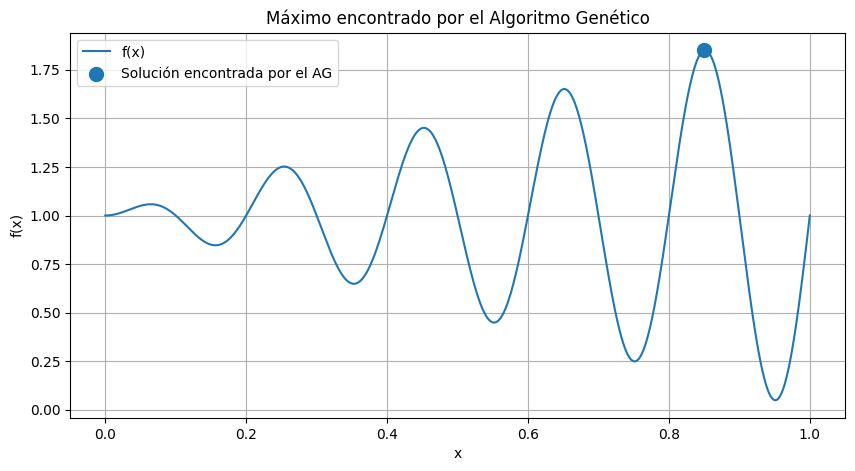

x ≈ 0.849462
f(x) ≈ 1.849341


In [ ]:
plt.figure(figsize=(10,5))
plt.plot(x_grafica, y_grafica, label="f(x)")
plt.scatter([mejor_x], [mejor_y], s=100, label="Solución encontrada por el AG")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Máximo encontrado por el Algoritmo Genético")
plt.grid()
plt.legend()
plt.show()

print(f"x ≈ {mejor_x:.6f}")
print(f"f(x) ≈ {mejor_y:.6f}")

# 15. Comprobación numérica

El ejercicio se resuelve mediante el algoritmo genético.

La siguiente búsqueda fina se utiliza **únicamente como verificación** de qué tan cerca quedó el AG del máximo de la función.

In [ ]:
x_validacion = np.linspace(0, 1, 1_000_001)
y_validacion = f(x_validacion)

indice = np.argmax(y_validacion)

x_referencia = x_validacion[indice]
y_referencia = y_validacion[indice]

print("Referencia numérica:")
print(f"x ≈ {x_referencia:.6f}")
print(f"f(x) ≈ {y_referencia:.6f}")

print("\nAlgoritmo genético:")
print(f"x ≈ {mejor_x:.6f}")
print(f"f(x) ≈ {mejor_y:.6f}")

print("\nError absoluto en x:")
print(abs(x_referencia - mejor_x))

Referencia numérica:
x ≈ 0.851190
f(x) ≈ 1.850595

Algoritmo genético:
x ≈ 0.849462
f(x) ≈ 1.849341

Error absoluto en x:
0.00172763440860213
